<div style="background-color:#ffffff; padding:14px 20px; border-radius:8px; display:flex; align-items:center; gap:16px;">
    <img src="https://s3.amazonaws.com/media-p.slid.es/uploads/1485763/images/9060062/Header.png" width="60"/>
    <div>
        <h1 style="font-size:26px; color:#6A0DAD; margin:0; white-space:nowrap;">Árboles de Decisión</h1>
        <p style="font-size:14px; color:#555; margin:2px 0 0 0;">Sesión 4 &middot; 4 de Abril 2026 &middot; Prof. Daniel Rambaut</p>
    </div>
</div>

En este notebook profundizaremos en uno de los modelos más interpretables del machine learning:

- **Árboles de Decisión** (modelo de machine learning supervisado)
- **Poda (Pruning)**: estrategias para evitar el sobreajuste
- **CCP (Cost Complexity Pruning)**: el método estándar de scikit-learn para la poda óptima

---
# <FONT SIZE=5 COLOR="green"> 0. Repaso de la sesión anterior </FONT>

En la sesión pasada exploramos herramientas para evaluar y mejorar modelos de clasificación. Los conceptos clave fueron:

<FONT COLOR="green" SIZE=3>1. Regresión Logística:</FONT>  
Un modelo que, a diferencia de predecir un número, predice la *probabilidad* de que algo ocurra. Por ejemplo: ¿qué tan probable es que este paciente tenga enfermedad cardíaca? Si esa probabilidad supera cierto umbral (normalmente 50%), el modelo dice "sí tiene enfermedad". Si no lo supera, dice "no tiene".

<FONT COLOR="green" SIZE=3>2. Curva ROC:</FONT>
<br>
Una gráfica que nos dice qué tan bien separa el modelo los casos positivos de los negativos. Cuanto más se acerca la curva a la esquina superior izquierda del gráfico, mejor es el modelo. Un modelo que adivina al azar produce una línea diagonal. El número que resume esta curva se llama **AUC** (Área Bajo la Curva): un valor cercano a 1.0 es excelente, y 0.5 es equivalente a lanzar una moneda.

<FONT COLOR="green" SIZE=3>3. Umbral de Decisión (Threshold):</FONT>
<br>El punto de corte que usamos para decidir cuándo el modelo dice "sí" o "no". El valor por defecto es 50%, pero podemos ajustarlo. Si bajamos el umbral (por ejemplo a 30%), el modelo será más "generoso" para decir "sí" — detectará más casos positivos pero también cometerá más errores. Si lo subimos, será más estricto. La decisión de dónde poner este umbral depende del problema: en medicina, preferimos detectar más casos aunque nos equivoquemos un poco, antes que dejar pasar enfermedades.

---

# <FONT SIZE=5 COLOR="blue"> 1. Introducción al modelo </FONT>


## <FONT SIZE=4 COLOR="blue"> 1.1 Librerías de trabajo </FONT>

In [50]:
# Manipulación de data.frames
import os
import pandas as pd
import numpy  as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler

# Árbol de Decisión
from sklearn.tree               import DecisionTreeClassifier, export_graphviz, plot_tree

# Métricas de evaluación
from sklearn.metrics            import (confusion_matrix, ConfusionMatrixDisplay,
                                        classification_report, accuracy_score,
                                        precision_score, recall_score, f1_score,
                                        roc_auc_score, roc_curve)
from imblearn.metrics           import specificity_score

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV, cross_val_score

# Para visualizar árboles
from graphviz import Source

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")


# Arregla el PATH para que Graphviz (el programa "dot") se encuentre,
# sin depender de reiniciar VS Code después de instalarlo
import shutil
if shutil.which("dot") is None:
    for _ruta in [r"C:\Program Files\Graphviz\bin", r"C:\Program Files (x86)\Graphviz\bin"]:
        if os.path.isdir(_ruta):
            os.environ["PATH"] += os.pathsep + _ruta
            break


<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Sistema de autoevaluación</p>

A lo largo del notebook encontrarás ejercicios donde completas código y seleccionas una respuesta (`"a"`, `"b"`, `"c"`...) o calculas un valor. Usa la función `verificar()` para saber al instante si acertaste.

Ejecuta la siguiente celda **una sola vez, al principio**; no necesitas entender cómo está construida.

</div>

In [51]:
# ============================================================
#  Sistema de autoevaluación — ejecútala una sola vez
#  (el banco solo guarda huellas digitales/hash de cada respuesta,
#   no las respuestas en sí, para que puedas dejar esta celda visible)
# ============================================================
import hashlib

_banco_respuestas = {}

def _hash(s):
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def _registrar(id_preg, hash_correcto, tipo="texto", precision=None, pista=None):
    _banco_respuestas[id_preg] = {"hash": hash_correcto, "tipo": tipo, "precision": precision, "pista": pista}

def verificar(id_preg, respuesta):
    """Verifica tu respuesta para el ejercicio indicado por id_preg."""
    info = _banco_respuestas.get(id_preg)
    if info is None:
        print(f"No reconozco el ejercicio '{id_preg}'.")
        return

    if info["tipo"] == "numero":
        try:
            texto = f"{float(respuesta):.{info['precision']}f}"
        except (TypeError, ValueError):
            print("Esa respuesta no parece un número. Intenta de nuevo.")
            return
    else:
        texto = str(respuesta).strip().lower()

    ok = _hash(texto) == info["hash"]

    if ok:
        print("Correcto.")
    else:
        msg = "Incorrecto, intenta de nuevo."
        if info["pista"]:
            msg += f" Pista: {info['pista']}"
        print(msg)

# ---- Banco de respuestas (solo hashes, no revelan la respuesta) ----
_registrar("warmup_auc", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Piensa en la escala del AUC: 0.5 es azar, 1.0 es perfecto.")
_registrar("balance_clases", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Compara los dos conteos: ¿son iguales, parecidos o uno domina fuertemente?")
_registrar("importancia_balance", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Piensa en un modelo que solo predice la clase mayoritaria.")
_registrar("gini_hoja1", "e6743df815da2b68bf6347dc8821a62d7609faefe384eb3cb7b74782864870e3", tipo="numero", precision=2, pista="Gini = 1 - (p0^2 + p1^2), con p0=9/10 y p1=1/10.")
_registrar("entropy_hoja1", "b440d5b1227fa50d5a1413a593f4777388144db3ec5ce126ab798efba0a0514b", tipo="numero", precision=2, pista="Entropía = -(p0*log2(p0) + p1*log2(p1)).")
_registrar("gini_hoja2", "f88afaea4207e3bdbf9381c1649835a1780019d246fe640dd86f1abe706462c0", tipo="numero", precision=2, pista="Con 5 y 5, es el caso de máxima impureza posible en dos clases.")
_registrar("entropy_hoja2", "cf9dcf6da8a82be1335c398a4005def7ee3a53d4698c59dbc6b2b14e72d1263c", tipo="numero", precision=2, pista="Con 50/50, la entropía alcanza su valor máximo.")
_registrar("reduce_impureza", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Calcula el Gini ponderado: 0.5*gini_hoja1 + 0.5*gini_hoja2, y compáralo con gini_padre.")
_registrar("ex2_2_a", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Gini=0 significa 0% de probabilidad de error al clasificar al azar dentro de ese nodo.")
_registrar("ex2_2_b", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="100% en entrenamiento y el modelo nunca se equivoca ahí, ¿es realista que generalice igual de bien?")
_registrar("ex2_2_c", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Compara el gap train-test en profundidad 8 contra profundidad 4.")
_registrar("ex2_3_root", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Es el tipo de dolor en el pecho — revisa el nodo superior del gráfico.")
_registrar("ex2_3_meaning", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="El algoritmo siempre elige primero la variable que más reduce la impureza.")
_registrar("ex2_3_pureleaf", "561b2814d3c09e62a92442c946307918f7f63f833c84876c08bd4c406767e53b", tipo="numero", precision=2, pista="Un árbol sin restricciones crece hasta que las hojas quedan puras.")
_registrar("ex2_4_cv_meaning", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="cv=10 es 'k-fold cross-validation' con k=10.")
_registrar("ex2_4_diff_depth", "4b227777d4dd1fc61c6f884f48641d02b4d121d3fd328cb08b5531fcacdabf8a", tipo="numero", precision=0, pista="Profundidad sin restricciones (8) menos profundidad óptima (4).")
_registrar("ex2_4_precision_recall", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Compara los valores de precision y recall de cada clase en la tabla.")
_registrar("ex3_1_fenomeno", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Es el mismo fenómeno que discutimos con el árbol de profundidad 8 vs 4.")
_registrar("ex3_2_depth_optima", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Busca dónde el accuracy de prueba llega a su punto más alto en la tabla.")
_registrar("ex3_2_overfit_start", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Es la primera profundidad donde el accuracy de prueba empieza a bajar.")
_registrar("ex3_2_vale_pena", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Una mejora de 13 puntos porcentuales suele considerarse sustancial.")
_registrar("ex3_3_mejor_depth", "4b227777d4dd1fc61c6f884f48641d02b4d121d3fd328cb08b5531fcacdabf8a", tipo="numero", precision=0, pista="Recorre los prints de tu loop y busca el mayor 'Test' accuracy.")
_registrar("ex3_3_mejor_minleaf", "4a44dc15364204a80fe80e9039455cc1608281820fe2b24f1e5233ade6af1dd5", tipo="numero", precision=0, pista="Entre las combinaciones con mejor accuracy de prueba, prioriza la más simple.")
_registrar("ex4_1_impureza_alpha", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Más poda (alpha alto) implica hojas más grandes y menos puras.")
_registrar("ex4_1_monotona", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Alpha controla poda de forma directa; accuracy depende de un balance sesgo-varianza.")
_registrar("ex4_2_sobreajuste_alpha0", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Compara 1.00 en entrenamiento contra 0.74 en prueba.")
_registrar("ex4_2_alpha_optimo", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Busca el accuracy de prueba más alto en la tabla hipotética.")
_registrar("ex4_2_alpha050", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Con train y test bajos y parecidos, el árbol ya no tiene capacidad suficiente.")
_registrar("ex4_3_alpha_categoria", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Un alpha cercano a 0 significa que casi no hace falta podar.")
_registrar("ex4_3_test_no_train", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="¿Qué alpha minimizaría siempre el error de entrenamiento?")
_registrar("ex5_1_top_var", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Es la misma variable que resultó ser la raíz del árbol en la sección 2.3.")
_registrar("ex5_1_sentido_clinico", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Piensa en cómo se diagnostica clínicamente una posible enfermedad cardíaca.")
_registrar("ex6_1_menos_hojas", "2e7d2c03a9507ae265ecf5b5356885a53393a2029d241394997265a1a25aefc6", tipo="texto", precision=None, pista="Compara la columna 'Hojas' de tu tabla comparativa entre los tres modelos.")
_registrar("ex6_1_accuracy_siempre", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="En medicina, dejar pasar un enfermo puede ser más costoso que una falsa alarma.")
_registrar("ex7_1_auc_max", "2e7d2c03a9507ae265ecf5b5356885a53393a2029d241394997265a1a25aefc6", tipo="texto", precision=None, pista="Revisa el valor de AUC en la leyenda de cada curva.")
_registrar("ex7_1_accuracy_vs_auc", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="El accuracy usa un único umbral (0.5); el AUC evalúa todos los umbrales posibles.")
_registrar("ex8_1_entropy_vs_gini", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Compara los dos accuracy de prueba que imprimiste: ¿difieren mucho o poco?")

print("Sistema de autoevaluación listo.")


Sistema de autoevaluación listo.


<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Antes de empezar — chequeo rápido</p>

Con base en la sesión anterior, responde:

**a)** Si un modelo tiene AUC = 0.95, es un modelo:
`a) excelente` &nbsp; `b) mediocre` &nbsp; `c) malo`

**b)** *(Reflexión, sin respuesta única — todavía no hemos visto árboles a fondo)* ¿Qué diferencia intuyes entre un árbol de decisión y una regresión logística? No hace falta que sea precisa, es solo una hipótesis para contrastar con lo que construiremos en este notebook.

</div>

In [52]:
respuesta_warmup_auc = "?"   # a, b o c
verificar("warmup_auc", respuesta_warmup_auc)

# b) Escribe tu hipótesis aquí (no se verifica automáticamente, es solo para pensar en voz alta):
#


Incorrecto, intenta de nuevo. Pista: Piensa en la escala del AUC: 0.5 es azar, 1.0 es perfecto.


## <FONT SIZE=4 COLOR="blue"> 1.2 Contexto del problema </FONT>

En este notebook usaremos el conjunto de datos **Heart Disease** del repositorio de la UCI (Cleveland Heart Disease Dataset).  
El objetivo es predecir si un paciente tiene o no enfermedad cardíaca a partir de variables clínicas.

- ***age***: Edad del paciente (años)
- ***sex***: Sexo (1 = masculino, 0 = femenino)
- ***cp***: Tipo de dolor en el pecho (0–3)
- ***trestbps***: Presión arterial en reposo (mm Hg)
- ***chol***: Colesterol sérico (mg/dl)
- ***fbs***: Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no)
- ***restecg***: Resultados del ECG en reposo (0–2)
- ***thalach***: Frecuencia cardíaca máxima alcanzada
- ***exang***: Angina inducida por ejercicio (1 = sí, 0 = no)
- ***oldpeak***: Depresión del ST inducida por ejercicio respecto al reposo
- ***slope***: Pendiente del segmento ST en el ejercicio pico (0–2)
- ***ca***: Número de vasos principales coloreados por fluoroscopía (0–3)
- ***thal***: Tipo de talasemia (0 = normal, 1 = defecto fijo, 2 = defecto reversible)
- ***target***: Variable que queremos predecir:
   - $1$ : Tiene enfermedad cardíaca
   - $0$ : No tiene enfermedad cardíaca

## <FONT SIZE=4 COLOR="blue"> 1.3 Importar los datos </FONT>

In [53]:
# Cargar los datos
heart = pd.read_csv("https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv")
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [54]:
# Forma del dataset y tipos de datos
print(f"Dimensiones: {heart.shape}")
print()
print(heart.dtypes)

Dimensiones: (303, 14)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [55]:
# Estadísticos descriptivos
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [56]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(heart.isnull().sum())

Valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


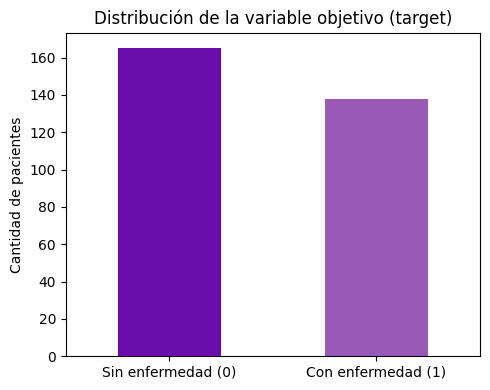

In [57]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(5,4))
heart["target"].value_counts().plot(kind="bar", color=["#6A0DAD","#9B59B6"], ax=ax)
ax.set_title("Distribución de la variable objetivo (target)")
ax.set_xticklabels(["Sin enfermedad (0)", "Con enfermedad (1)"], rotation=0)
ax.set_ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.show()

<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 1.1 — Balance de clases</p>

Observando el gráfico de barras anterior:

**a)** El dataset está:
`a)` perfectamente balanceado (50/50) &nbsp; `b)` moderadamente balanceado, sin desbalance severo &nbsp; `c)` fuertemente desbalanceado

**b)** ¿Por qué importa el balance de clases al evaluar con accuracy?
`a)` Porque con clases muy desbalanceadas, un modelo trivial que siempre predice la clase mayoritaria puede tener accuracy alto sin ser útil.
`b)` Porque el accuracy solo funciona con datos balanceados y da error si no lo están.
`c)` El balance de clases no afecta la evaluación.

</div>

In [58]:
respuesta_1_1a = "?"   # a, b o c
respuesta_1_1b = "?"   # a, b o c

verificar("balance_clases", respuesta_1_1a)
verificar("importancia_balance", respuesta_1_1b)


Incorrecto, intenta de nuevo. Pista: Compara los dos conteos: ¿son iguales, parecidos o uno domina fuertemente?
Incorrecto, intenta de nuevo. Pista: Piensa en un modelo que solo predice la clase mayoritaria.


# <FONT SIZE=5 COLOR="purple"> 2. Árboles de Decisión </FONT>

- El enfoque de clasificación y regresión vía árboles (CART, classification and regression tree) fue desarrollado por Breiman et al. (1984).

- Un árbol de decisión es una estructura que incluye un ***nodo raíz, nodos principales, ramas y nodos hoja***. Cada nodo interno denota una prueba sobre un atributo, cada rama denota el resultado de una prueba y cada nodo hoja contiene una etiqueta de clase. El nodo superior del árbol también es llamado: **nodo raíz**.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree1.png?raw=true" alt="centered image" width="500" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Los términos que intervienen en el algoritmo de árbol de decisión son los siguientes

- ***Nodo raíz:***: Es el nodo inicial del árbol.

- ***División:*** Es un proceso de división de un nodo en dos o más subnodos.

- ***Nodo de decisión***: Cuando un subnodo se divide en otros subnodos, se denomina nodo de decisión.

- ***Nodo hoja/terminal***: Son los nodos que no se dividen más.

- ***Rama/Subárbol***:  Una subsección de un árbol completo que inicia con un nodo principal.

- ***Profundidad (depth):*** Es el número de niveles de decisión en el árbol.

- ***Poda (prunning)***: Es el proceso de eliminar nodos de decisión con el fin de hacer el árbol más pequeño

Esta técnica de machine learning toma una serie de decisiones binarias en forma de árbol. Los nodos intermedios (las ramas) representan soluciones y los nodos finales (las hojas) nos dan la predicción que buscamos.

Para seleccionar las condiciones que conforman el árbol se usan dos elementos que se describirán más adelante.

  - Indice de Gini
  - Ganancia de Información (Entropía)


Lo primero que debemos indicar es que el algoritmo se basa en una serie de decisiones binarias, que gráficamente, no es más que una división de una región del plano donde están los datos.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree2.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Esta división se hace con el fin de separar un conjunto de puntos en las clases correspondientes. Consideremos el siguiente conjunto de puntos:

$$\{(x_i,y_i) \mid i = 1,2,3, \dots 29\}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree13.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Buscamos hacer divisiones rectangulares con el fin de separar los puntos. Para esto debemos iniciar con una condición, pero ¿cómo se hace esto?

Para responder está pregunta debemos hacer una grilla o cuadrícula tomando como referencia puntos entre cada $(x_i,x_{i+1}$) y $(y_i,y_{i+1})$.Por lo general se toma el punto medio

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree3.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora, debemos determinar cuál condición $x \leq x_i$ o $y \leq y_j$ es más apropiada para iniciar. Esta condición nos dará el nodo raíz que es el inicio del algoritmo.

Es en este punto donde debemos tener un criterio de decisión. Para ello hay dos alternativas: usar el índice de Gini o la Entropía, con el fin de determinar la mejor condición.

- El índice de Gini dice que, si seleccionamos al azar dos elementos de una población, deben ser de la misma clase y la probabilidad de que esto ocurra es 1 si la población es pura. En otras palabras, este índice permite determinar si un conjunto de puntos es homogéneo o no.

- Este índice funciona con la variable objetivo categórica "Éxito" o "Fracaso". Sólo realiza divisiones binarias.

*Cuanto menor sea el valor de Gini, mayor será la homogeneidad.*

- El **índice de Gini** está dado en general como:

$$Gini = 1-\sum \limits_{k=1}^{n}p_k^2$$

donde $p_k$ es la probabilidad de seleccionar un objeto de la clase $k$ en un determinado nodo.

Veamos un ejemplo de dos condiciones:

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree14.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora bien, para determinar si elegimos una condición o no, usaremos el concepto de *impureza*, que se define de la siguiente manera

$$\text{Impureza de un nodo} = (Gini) \times (\text{Ponderacion de los nodos})$$

Supongamos que en nuestro ejemplo ( de los puntos dados arriba) queremos saber cuál condición es mejor, es decir, tiene un nivel de impureza menor.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree5.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Es importante resaltar que el algoritmo compara todas las impurezas y escoje la menor. En ese sentido, la función de costo para los árboles de clasificación es:

$$\text{función de costo} = 1-\sum \limits_{k=1}^{n}p_k^2$$

Partiendo de esta condición, comenzamos la división en el árbol buscando minimizar esta función.


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 2.1 — Calcula el índice de Gini y la Entropía</p>

El índice de Gini no es el único criterio de impureza: el otro es la **Entropía**, definida como

$$Entropía = -\sum_{k=1}^{n} p_k \log_2(p_k)$$

Ambos miden lo mismo (qué tan "mezclado" está un nodo) pero con fórmulas distintas.

Supón un nodo con 20 pacientes: 14 sin enfermedad y 6 con enfermedad, que se divide en dos hojas: **hoja 1** (9 sin, 1 con) y **hoja 2** (5 sin, 5 con).

Completa el código de abajo (ya tienes `gini()` y `entropy()`, y los valores del nodo padre) y calcula Gini y Entropía para cada hoja.

</div>

In [ ]:
def gini(clases):
    total = sum(clases)
    ps = [c / total for c in clases]
    return 1 - sum(p**2 for p in ps)

def entropy(clases):
    total = sum(clases)
    ps = [c / total for c in clases if c > 0]
    return -sum(p * np.log2(p) for p in ps)

nodo_padre = [14, 6]
hoja_1     = [9, 1]
hoja_2     = [5, 5]

gini_padre    = gini(nodo_padre)
entropy_padre = entropy(nodo_padre)

# Completa tú (reemplaza los ... por tu código):
gini_hoja1    = ...
entropy_hoja1 = ...
gini_hoja2    = ...
entropy_hoja2 = ...

if Ellipsis in (gini_hoja1, entropy_hoja1, gini_hoja2, entropy_hoja2):
    print("Todavía te falta completar alguna de las 4 líneas de arriba (los ...).")
else:
    print(f"Padre  -> Gini: {gini_padre:.4f} | Entropía: {entropy_padre:.4f}")
    print(f"Hoja 1 -> Gini: {gini_hoja1:.4f} | Entropía: {entropy_hoja1:.4f}")
    print(f"Hoja 2 -> Gini: {gini_hoja2:.4f} | Entropía: {entropy_hoja2:.4f}")

    verificar("gini_hoja1", gini_hoja1)
    verificar("entropy_hoja1", entropy_hoja1)
    verificar("gini_hoja2", gini_hoja2)
    verificar("entropy_hoja2", entropy_hoja2)


Todavía te falta completar alguna de las 4 líneas de arriba (los ...).


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

**¿La división anterior reduce la impureza respecto al nodo original?**
`a)` Sí, el Gini ponderado de las hojas es menor que el del nodo padre &nbsp; `b)` No &nbsp; `c)` No se puede saber

</div>

In [60]:
respuesta_reduce_impureza = "?"   # a, b o c
verificar("reduce_impureza", respuesta_reduce_impureza)


Incorrecto, intenta de nuevo. Pista: Calcula el Gini ponderado: 0.5*gini_hoja1 + 0.5*gini_hoja2, y compáralo con gini_padre.


En las siguientes imágenes se observan las divisiones del árbol para diferentes valores

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree4.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree6.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree7.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

**Observación:** El método de árboles de decisión busca minimizar el índice de Gini y esto se puede lograr dividiendo el árbol de manera exhaustiva. Es decir, practicamente que cada punto este en una región. Pero esto es malo, ya que estamos *sobreajustando* el modelo. En otras palabras, el modelo clasifica perfectamente los datos del conjunto de entrenamiento pero no clasificará bien en los datos de prueba.

## <FONT SIZE=4 COLOR="purple"> 2.1 Modelo base del árbol de decisión </FONT>

In [61]:
# 1. Definir variables
X = heart.drop("target", axis=1)
y = heart["target"]

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify    = y,
    random_state = 123,
    test_size   = 0.3 # ¿De qué tamaño quedó el test y el train?
)

# 3. Árbol sin restricciones (crecimiento máximo)
modelo_tree = DecisionTreeClassifier(random_state=123)
modelo_tree.fit(X_train, y_train) # Entrenamiento del modelo

# 4. Predicciones
y_pred = modelo_tree.predict(X_test)

# 5. Métricas
print("Profundidad del árbol:", modelo_tree.get_depth())
print("Número de hojas:      ", modelo_tree.get_n_leaves())
print()
print("========== Evaluación Árbol sin poda ==========")
print(classification_report(y_test, y_pred))

Profundidad del árbol: 9
Número de hojas:       34

========== Evaluación Árbol sin poda ==========
              precision    recall  f1-score   support

           0       0.66      0.80      0.73        41
           1       0.80      0.66      0.73        50

    accuracy                           0.73        91
   macro avg       0.73      0.73      0.73        91
weighted avg       0.74      0.73      0.73        91



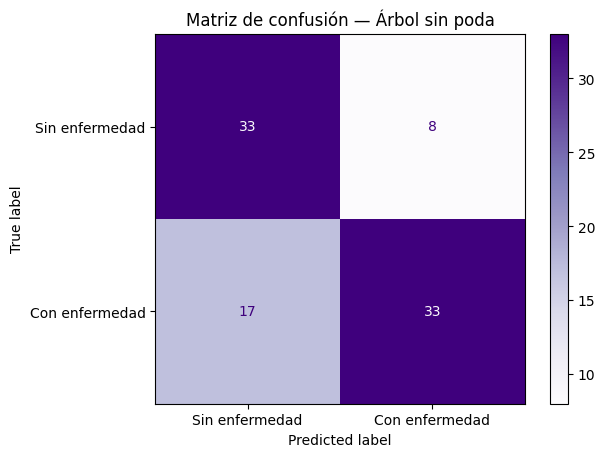

In [62]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Sin enfermedad","Con enfermedad"])
disp.plot(cmap="Purples")
plt.title("Matriz de confusión — Árbol sin poda")
plt.show()

In [63]:
# Métricas resumidas
metrics = ["accuracy", "recall", "specificidad", "precision", "f1"]
values  = [accuracy_score(y_test, y_pred),
           recall_score(y_test, y_pred),
           specificity_score(y_test, y_pred),
           precision_score(y_test, y_pred),
           f1_score(y_test, y_pred)]
metricas_base = pd.DataFrame({"metric": metrics, "value": values})
metricas_base

,metric,value
0,accuracy,0.725275
1,recall,0.660000
2,specificidad,0.804878
3,precision,0.804878
4,f1,0.725275


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 2.2 — Análisis conceptual</p>

**a)** Que un nodo tenga **Gini = 0** significa que es puro (todas sus muestras son de la misma clase). ¿Es eso bueno o malo?
`a)` bueno &nbsp; `b)` malo &nbsp; `c)` depende

*¿Por qué?* — respóndelo abajo, en la celda de código.

**b)** ¿Qué sucede si el árbol tiene un accuracy del 100% en entrenamiento? ¿Es bueno o malo?
`a)` bueno &nbsp; `b)` malo (posible sobreajuste) &nbsp; `c)` neutro, no dice nada

*Explica* — respóndelo abajo.

**c)** Si el árbol sin poda tiene una profundidad de 9 y el árbol con GridSearch encontró que la profundidad óptima es 4-5, ¿qué le está pasando al árbol sin poda con los datos de entrenamiento? ¿Y con los de prueba?
`a)` En entrenamiento memoriza casi perfectamente, pero en prueba su desempeño es peor de lo esperado (sobreajuste)
`b)` En entrenamiento falla, y en prueba también
`c)` No hay diferencia entre entrenamiento y prueba

</div>

In [64]:
respuesta_2_2a = "?"
respuesta_2_2b = "?"
respuesta_2_2c = "?"

verificar("ex2_2_a", respuesta_2_2a)
verificar("ex2_2_b", respuesta_2_2b)
verificar("ex2_2_c", respuesta_2_2c)

# a) ¿Por qué? (no se verifica automáticamente):
#

# b) Explica (no se verifica automáticamente):
#


Incorrecto, intenta de nuevo. Pista: Gini=0 significa 0% de probabilidad de error al clasificar al azar dentro de ese nodo.
Incorrecto, intenta de nuevo. Pista: 100% en entrenamiento y el modelo nunca se equivoca ahí, ¿es realista que generalice igual de bien?
Incorrecto, intenta de nuevo. Pista: Compara el gap train-test en profundidad 8 contra profundidad 4.


## <FONT SIZE=4 COLOR="purple"> 2.2 Visualización del árbol </FONT>

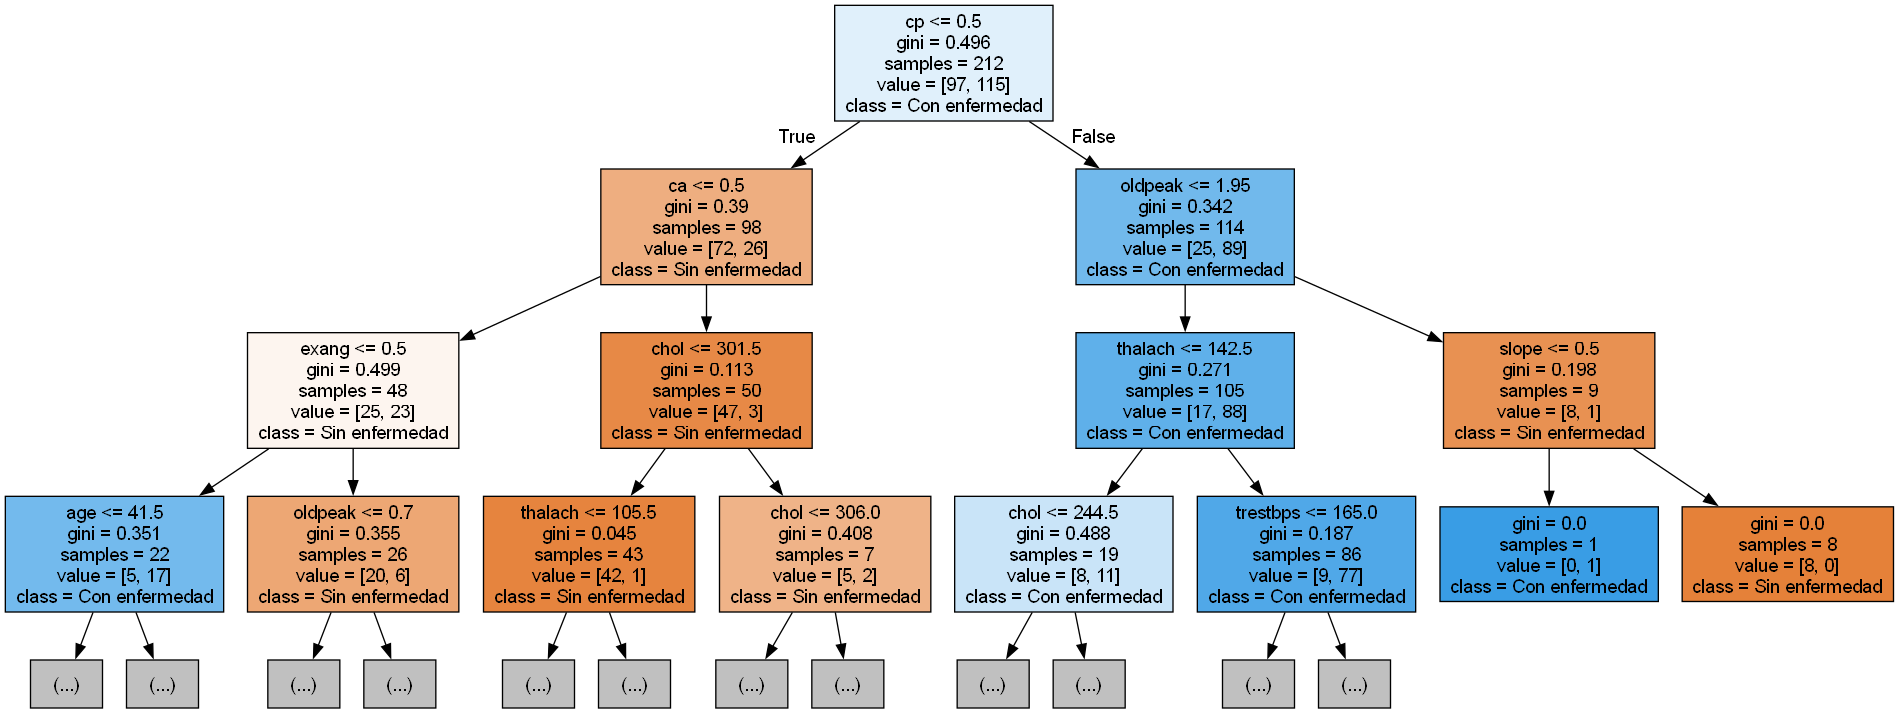

In [65]:
from sklearn.tree import export_graphviz
from graphviz     import Source

dot_data = export_graphviz(
    modelo_tree,
    feature_names = X.columns,
    class_names   = ["Sin enfermedad", "Con enfermedad"],
    filled        = True,
    max_depth     = 3         # mostramos solo los primeros 3 niveles para legibilidad (variar)
)
from IPython.display import Image
Image(Source(dot_data, format="png").pipe(format="png"), width=700)

### <FONT SIZE=3 COLOR="purple"> ¿Cómo leer este árbol? </FONT>

Cada rectángulo (nodo) muestra:
- **La pregunta** que se hace (por ejemplo: `ca <= 0.5`)
- **gini**: el nivel de impureza de ese nodo (cercano a 0 = muy puro)
- **samples**: cuántos pacientes del entrenamiento llegaron a ese nodo
- **value**: cuántos son de cada clase `[sin enfermedad, con enfermedad]`
- **class**: la clase mayoritaria en ese nodo (la predicción si se detuviera aquí)

Los nodos en **tono más intenso** son los más puros.

<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 2.3 — Lee el árbol</p>

Observa el árbol que graficaste arriba (primeros 3 niveles).

**a)** ¿Cuál variable fue elegida como nodo raíz?
`a)` age &nbsp; `b)` cp &nbsp; `c)` thalach &nbsp; `d)` chol

**b)** ¿Qué te dice eso sobre esa variable?
`a)` Es la que, sola, logra la mayor reducción de impureza al dividir los datos.
`b)` Es la variable con mayor rango numérico.
`c)` Es la primera columna del dataset, por eso se usa primero.

**c)** Ejecuta el código de abajo para encontrar el Gini de la hoja más pura de tu árbol (`modelo_tree`, sin restricciones) y verifica tu resultado.

</div>

In [66]:
respuesta_2_3a = "?"
respuesta_2_3b = "?"

verificar("ex2_3_root", respuesta_2_3a)
verificar("ex2_3_meaning", respuesta_2_3b)

hojas_gini = modelo_tree.tree_.impurity[modelo_tree.tree_.children_left == -1]
gini_hoja_mas_pura = hojas_gini.min()
print("Gini de la hoja más pura:", round(gini_hoja_mas_pura, 4))

verificar("ex2_3_pureleaf", gini_hoja_mas_pura)


Incorrecto, intenta de nuevo. Pista: Es el tipo de dolor en el pecho — revisa el nodo superior del gráfico.
Incorrecto, intenta de nuevo. Pista: El algoritmo siempre elige primero la variable que más reduce la impureza.
Gini de la hoja más pura: 0.0
Correcto.


## <FONT SIZE=4 COLOR="purple"> 2.3 Hiperparámetros y búsqueda en grilla </FONT>

Los principales hiperparámetros de un árbol de decisión son:

<table style="border-collapse:collapse; width:100%;">
<thead><tr style="background-color:#6A0DAD; color:#ffffff;"><th style="padding:8px 12px; text-align:left;">Hiperparámetro</th><th style="padding:8px 12px; text-align:left;">Descripción</th></tr></thead>
<tbody>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>criterion</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Criterio de impureza: <code>gini</code> o <code>entropy</code></td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>max_depth</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Profundidad máxima del árbol</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>min_samples_split</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Mínimo de muestras para dividir un nodo</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>min_samples_leaf</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Mínimo de muestras en un nodo hoja</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>max_features</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Número máximo de variables candidatas por división</td></tr>
</tbody>
</table>

<div style="display:inline-block; background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:8px 16px; margin:16px 0 0 0; border-radius:4px; font-size:14px;">
Los más influyentes suelen ser <code>criterion</code> y <code>max_depth</code>.
</div>

In [67]:
# Búsqueda en grilla
modelo_gs = DecisionTreeClassifier(random_state=123)

grid_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None] + list(range(2, 12))
}

grid_tree = GridSearchCV(
    modelo_gs,
    grid_params,
    cv      = 10,
    scoring = "accuracy",
    verbose = 1
)

grid_tree.fit(X_train, y_train)

Fitting 10 folds for each of 22 candidates, totalling 220 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=123),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]},
             scoring='accuracy', verbose=1)

In [68]:
print("Mejor accuracy (CV):", round(grid_tree.best_score_, 4))
print("Mejores hiperparámetros:", grid_tree.best_params_)
modelo_tree_best = grid_tree.best_estimator_

Mejor accuracy (CV): 0.8115
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 5}


In [69]:
# Evaluación del mejor modelo de grilla
y_pred_best = modelo_tree_best.predict(X_test)
print("========== Evaluación — Mejor árbol (GridSearch) ==========")
print(classification_report(y_test, y_pred_best))

========== Evaluación — Mejor árbol (GridSearch) ==========
              precision    recall  f1-score   support

           0       0.70      0.78      0.74        41
           1       0.80      0.72      0.76        50

    accuracy                           0.75        91
   macro avg       0.75      0.75      0.75        91
weighted avg       0.75      0.75      0.75        91



Matriz de confusión:
[[32  9]
 [14 36]]


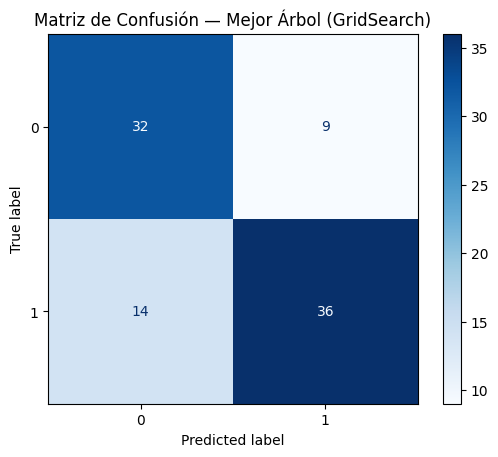

In [70]:
cm = confusion_matrix(y_test, y_pred_best)
print("Matriz de confusión:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión — Mejor Árbol (GridSearch)")
plt.show()

<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 2.4 — Interpretar la salida del GridSearch</p>

Después de ejecutar el GridSearch, observa la siguiente salida hipotética:

```
Mejor accuracy (CV): 0.8123
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 4}
```

Y el reporte de clasificación del modelo óptimo da:
```
              precision    recall  f1-score   support

           0       0.78      0.83      0.80        41
           1       0.84      0.79      0.81        50

    accuracy                           0.81        91
```

**a)** El GridSearch usó `cv=10`. ¿Qué significa eso en términos de cómo se evaluó el modelo?
`a)` Los datos de entrenamiento se dividieron en 10 partes; el modelo se entrenó y validó 10 veces, usando cada vez una parte distinta para validar
`b)` El árbol tiene 10 niveles de profundidad
`c)` Se probaron 10 combinaciones distintas de hiperparámetros

**b)** La profundidad óptima fue 4. Si la profundidad sin restricciones era 8, ¿cuántos niveles se "recortaron"?

**c)** ¿Cuál clase tiene mejor **precision** y cuál tiene mejor **recall**?
`a)` Clase 0 tiene mejor precision y clase 1 mejor recall
`b)` Clase 1 tiene mejor precision y clase 0 mejor recall

*¿Qué implicación clínica tiene eso?* — respóndelo abajo, en la celda de código.

</div>

In [71]:
respuesta_2_4a = "?"
respuesta_2_4b = "?"   # número: niveles recortados
respuesta_2_4c = "?"

verificar("ex2_4_cv_meaning", respuesta_2_4a)
verificar("ex2_4_diff_depth", respuesta_2_4b)
verificar("ex2_4_precision_recall", respuesta_2_4c)

# Implicación clínica (no se verifica automáticamente):
#


Incorrecto, intenta de nuevo. Pista: cv=10 es 'k-fold cross-validation' con k=10.
Esa respuesta no parece un número. Intenta de nuevo.
Incorrecto, intenta de nuevo. Pista: Compara los valores de precision y recall de cada clase en la tabla.


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 2.5 — Exploración práctica de hiperparámetros</p>

Modifica el siguiente código para experimentar con el árbol:

```python
mi_arbol = DecisionTreeClassifier(
    criterion        = "gini",     # Prueba también: "entropy"
    max_depth        = 4,          # Prueba: 2, 6, 10, None
    min_samples_leaf = 1,          # Prueba: 5, 10, 20
    random_state     = 123
)
mi_arbol.fit(X_train, y_train)
y_pred_mio = mi_arbol.predict(X_test)

print(f"Profundidad: {mi_arbol.get_depth()} | Hojas: {mi_arbol.get_n_leaves()}")
print(f"Accuracy en entrenamiento: {accuracy_score(y_train, mi_arbol.predict(X_train)):.4f}")
print(f"Accuracy en prueba:        {accuracy_score(y_test, y_pred_mio):.4f}")
```

</div>

In [72]:
# Tu código aquí

Llena la siguiente tabla con tus resultados:

| `max_depth` | `min_samples_leaf` | Acc. entrenamiento | Acc. prueba | ¿Sobreajuste? |
|---|---|---|---|---|
| None | 1 | | | |
| 4 | 1 | | | |
| 2 | 1 | | | |
| 4 | 10 | | | |
| 4 | 20 | | | |

¿Qué conclusión sacas sobre la relación entre profundidad, tamaño de hojas y sobreajuste?

# <FONT SIZE=5 COLOR="purple"> 3. Poda (Pruning) </FONT>

Los árboles de decisión, cuando se les permite crecer libremente, tienden a aprender ruido y patrones muy específicos a partir de los datos de entrenamiento, lo que lleva a un ajuste excesivo. La **poda** aborda este problema simplificando la estructura del árbol, mejorando la generalización de los datos invisibles, mejorando la interpretabilidad y reduciendo el costo computacional, al tiempo que mantiene o incluso mejora la precisión general del modelo.

- Reduce el sobreajuste eliminando las divisiones impulsadas por el ruido
- Mejora la generalización de los datos invisibles
- Simplifica la estructura del árbol de decisión
- Mejora la interpretabilidad de las normas de decisión
- Mejora la formación y la eficiencia de la inferencia

La poda de árbol de decisión es una técnica de optimización de modelos utilizada para controlar el crecimiento de modelos de árboles de decisión mediante la eliminación de ramas y nodos innecesarios que no contribuyen significativamente al rendimiento predictivo.

<center>
  <img src="https://miro.medium.com/v2/1*7BjLEC5vSpBXnD3sPhzEsQ.png" width="700"/>
  <br>
  <small>
    Fuente: https://medium.com/@sushmita2310/a-comprehensive-guide-to-pre-pruning-and-post-pruning-in-decision-trees-c556c48aafdf
  </small>
</center>

<br>
Existen dos grandes estrategias de poda:

1. **Pre-poda (Pre-pruning)**: se detiene el crecimiento del árbol de forma anticipada, imponiendo restricciones durante el entrenamiento (por ejemplo, `max_depth`, `min_samples_leaf`).

2. **Post-poda (Post-pruning)**: primero se deja crecer el árbol completamente y luego se eliminan ramas según algún criterio. El método más común en scikit-learn es el **CCP** (Cost Complexity Pruning).

<br>

<table style="border-collapse:collapse; width:100%;">
<thead><tr style="background-color:#2471A3; color:#ffffff;"><th style="padding:8px 12px; text-align:left;">Estrategia</th><th style="padding:8px 12px; text-align:left;">Ventaja</th><th style="padding:8px 12px; text-align:left;">Desventaja</th></tr></thead>
<tbody>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Pre-poda</td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Más rápida, fácil de interpretar</td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Puede detener el árbol antes de tiempo</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Post-poda</td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Más precisa, explora más soluciones</td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Más costosa computacionalmente</td></tr>
</tbody>
</table>

## <FONT SIZE=4 COLOR="blue"> 3.1 Pre-poda (Pre-pruning) </FONT>

En la pre-poda restringimos el crecimiento del árbol desde el inicio usando los hiperparámetros que ya conocemos.  
Veamos el efecto de variar la profundidad máxima (`max_depth`) sobre el rendimiento en entrenamiento y prueba.

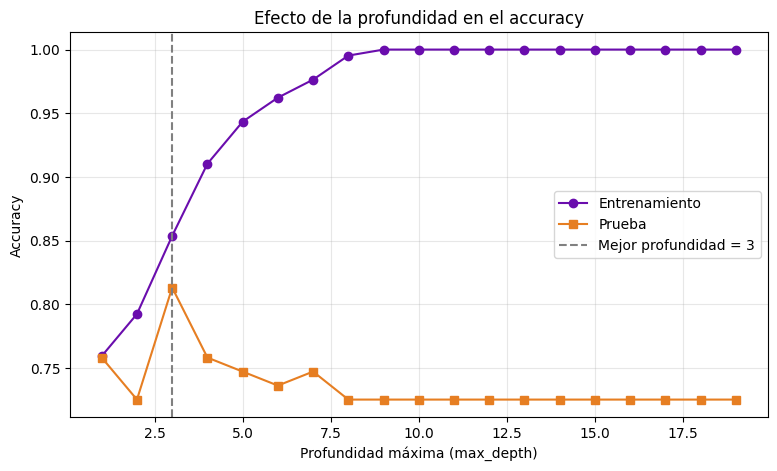

Mejor profundidad sobre prueba: 3  |  Accuracy: 0.8132


In [73]:
# Efecto de max_depth sobre accuracy de entrenamiento y prueba
train_scores = []
test_scores  = []
depths       = list(range(1, 20))

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=123)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker="o", label="Entrenamiento", color="#6A0DAD")
plt.plot(depths, test_scores,  marker="s", label="Prueba",        color="#E67E22")
plt.axvline(depths[test_scores.index(max(test_scores))],
            linestyle="--", color="gray", label=f"Mejor profundidad = {depths[test_scores.index(max(test_scores))]}")
plt.xlabel("Profundidad máxima (max_depth)")
plt.ylabel("Accuracy")
plt.title("Efecto de la profundidad en el accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(f"Mejor profundidad sobre prueba: {best_depth}  |  Accuracy: {max(test_scores):.4f}")

In [74]:
# Modelo con pre-poda (mejor max_depth encontrado)
modelo_prepoda = DecisionTreeClassifier(max_depth=best_depth, random_state=123)
modelo_prepoda.fit(X_train, y_train)
y_pred_prepoda = modelo_prepoda.predict(X_test)

print(f"Profundidad: {modelo_prepoda.get_depth()}  |  Hojas: {modelo_prepoda.get_n_leaves()}")
print()
print("========== Evaluación — Árbol con pre-poda ==========")
print(classification_report(y_test, y_pred_prepoda))

Profundidad: 3  |  Hojas: 8

========== Evaluación — Árbol con pre-poda ==========
              precision    recall  f1-score   support

           0       0.82      0.76      0.78        41
           1       0.81      0.86      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



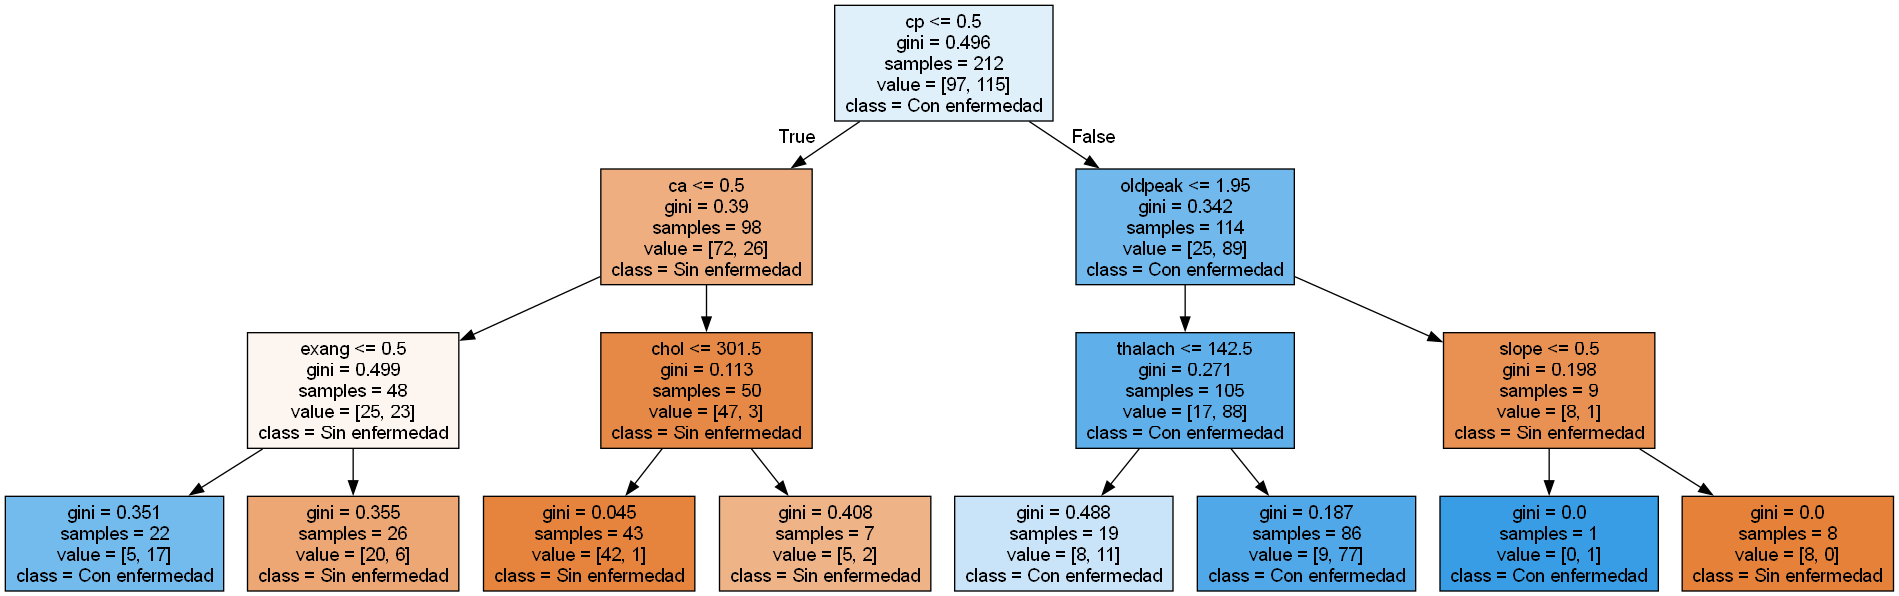

In [75]:
# Visualización del árbol podado
dot_prepoda = export_graphviz(
    modelo_prepoda,
    feature_names = X.columns,
    class_names   = ["Sin enfermedad", "Con enfermedad"],
    filled        = True
)
from IPython.display import Image
Image(Source(dot_prepoda, format="png").pipe(format="png"), width=700)

<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 3.1 — Análisis conceptual</p>

Observa la gráfica de "profundidad vs accuracy" que acabas de generar. A partir de cierta profundidad, el accuracy de entrenamiento sigue subiendo pero el de prueba se estanca o baja.

**a)** ¿Cómo se llama ese fenómeno?
`a)` sobreajuste (overfitting) &nbsp; `b)` subajuste (underfitting) &nbsp; `c)` validación cruzada

*¿Por qué ocurre?* — respóndelo abajo.

**b)** *(Reflexión, sin respuesta única)* ¿Por qué no conviene siempre elegir el árbol más profundo, si ese maximiza el accuracy en entrenamiento?

**c)** *(Reflexión, sin respuesta única)* Explica con una analogía cotidiana (no técnica) la diferencia entre un árbol que "memoriza" y uno que "aprende".

</div>

In [76]:
respuesta_3_1a = "?"

verificar("ex3_1_fenomeno", respuesta_3_1a)

# ¿Por qué ocurre? (no se verifica automáticamente):
#

# c) Escribe tu analogía aquí (no se verifica automáticamente):
#


Incorrecto, intenta de nuevo. Pista: Es el mismo fenómeno que discutimos con el árbol de profundidad 8 vs 4.


<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 3.2 — Interpretar una gráfica de profundidad (caso hipotético)</p>

Observa esta gráfica hipotética (distinta a la tuya) de profundidad vs accuracy:

```
Profundidad  | Acc. Entrenamiento | Acc. Prueba
-------------+---------------------+-------------
     1        |       0.72         |    0.70
     2        |       0.78         |    0.76
     3        |       0.83         |    0.81
     4        |       0.87         |    0.83
     5        |       0.91         |    0.82
     8        |       0.98         |    0.78
    12        |       1.00         |    0.74
```

**a)** ¿Cuál sería la profundidad óptima según esta tabla?
`a)` 1 &nbsp; `b)` 4 &nbsp; `c)` 12

*¿Por qué?* — respóndelo abajo.

**b)** ¿En qué profundidad empieza claramente a caer el accuracy de prueba?
`a)` 3 &nbsp; `b)` 5 &nbsp; `c)` 8

**c)** Un árbol con profundidad 1 tiene accuracy de 0.70 en prueba y el óptimo (profundidad 4) tiene 0.83. ¿Vale la pena la complejidad extra del árbol más profundo?
`a)` sí, la mejora es sustancial y la profundidad 4 sigue siendo interpretable
`b)` no, la diferencia es insignificante
`c)` no se puede determinar

</div>

In [77]:
respuesta_3_2a = "?"
respuesta_3_2b = "?"
respuesta_3_2c = "?"

verificar("ex3_2_depth_optima", respuesta_3_2a)
verificar("ex3_2_overfit_start", respuesta_3_2b)
verificar("ex3_2_vale_pena", respuesta_3_2c)

# a) ¿Por qué? (no se verifica automáticamente):
#


Incorrecto, intenta de nuevo. Pista: Busca dónde el accuracy de prueba llega a su punto más alto en la tabla.
Incorrecto, intenta de nuevo. Pista: Es la primera profundidad donde el accuracy de prueba empieza a bajar.
Incorrecto, intenta de nuevo. Pista: Una mejora de 13 puntos porcentuales suele considerarse sustancial.


<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 3.3 — Exploración: efectos combinados de pre-poda</p>

Experimenta combinando dos hiperparámetros de pre-poda simultáneamente:

```python
for depth in [2, 4, 6]:
    for min_leaf in [1, 5, 10]:
        clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=min_leaf, random_state=123)
        clf.fit(X_train, y_train)
        acc_train = accuracy_score(y_train, clf.predict(X_train))
        acc_test  = accuracy_score(y_test, clf.predict(X_test))
        print(f"depth={depth}, min_leaf={min_leaf} | Train: {acc_train:.3f} | Test: {acc_test:.3f}")
```

Ejecuta el código en la celda de abajo y, con base en lo que imprime, identifica la combinación (`depth`, `min_leaf`) con mejor accuracy de prueba (si hay empate, prioriza la más simple).

</div>

In [78]:
for depth in [2, 4, 6]:
    for min_leaf in [1, 5, 10]:
        clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=min_leaf, random_state=123)
        clf.fit(X_train, y_train)
        acc_train = accuracy_score(y_train, clf.predict(X_train))
        acc_test  = accuracy_score(y_test, clf.predict(X_test))
        print(f"depth={depth}, min_leaf={min_leaf} | Train: {acc_train:.3f} | Test: {acc_test:.3f}")


depth=2, min_leaf=1 | Train: 0.792 | Test: 0.725
depth=2, min_leaf=5 | Train: 0.792 | Test: 0.725
depth=2, min_leaf=10 | Train: 0.783 | Test: 0.725
depth=4, min_leaf=1 | Train: 0.910 | Test: 0.758
depth=4, min_leaf=5 | Train: 0.882 | Test: 0.769
depth=4, min_leaf=10 | Train: 0.840 | Test: 0.780
depth=6, min_leaf=1 | Train: 0.962 | Test: 0.736
depth=6, min_leaf=5 | Train: 0.882 | Test: 0.736
depth=6, min_leaf=10 | Train: 0.840 | Test: 0.780


In [79]:
mejor_depth = "?"
mejor_minleaf = "?"

verificar("ex3_3_mejor_depth", mejor_depth)
verificar("ex3_3_mejor_minleaf", mejor_minleaf)


Esa respuesta no parece un número. Intenta de nuevo.
Esa respuesta no parece un número. Intenta de nuevo.


# <FONT SIZE=5 COLOR="green"> 4. CCP — Cost Complexity Pruning (Post-poda) </FONT>

El **Cost Complexity Pruning (CCP)**, también conocido como *Weakest Link Pruning*, es la técnica de **post-poda** utilizada en árboles de decisión en `scikit-learn` por defecto.
<br>

<FONT SIZE=4 COLOR="green"> **Idea intuitiva** </FONT>

Cuando entrenamos un árbol de decisión sin restricciones, este tiende a crecer mucho y a ajustarse demasiado a los datos de entrenamiento (*overfitting*). Esto genera ramas que capturan ruido en lugar de patrones reales.
<br>
<br>

El CCP propone una idea sencilla:  
**no todas las ramas del árbol valen la pena.**
<br>
<br>

Cada rama adicional hace el modelo más complejo. Entonces, el algoritmo evalúa si esa complejidad extra realmente mejora el rendimiento. Si una rama no aporta suficiente mejora, se elimina.
<br>

Es como tener un "presupuesto de complejidad":
- Cada nueva rama tiene un costo.
- Si el beneficio no justifica ese costo, la rama se poda.
<br>
<br>

El parámetro clave es **α (alpha)**, que controla qué tan estricto eres con ese presupuesto:

- **α = 0**: no hay penalización, el árbol crece al máximo.
- **α pequeño**: se eliminan solo las ramas menos útiles.
- **α grande**: se poda de forma agresiva → árbol más simple.
<br>
<br>

El objetivo es encontrar un valor de α que logre un equilibrio entre:
- buen rendimiento
- baja complejidad
<br>
<br>

<FONT SIZE=4 COLOR="green"> **Intuición del algoritmo** </FONT>

El proceso es:
1. Se entrena un árbol completo (sin restricciones).
2. Se evalúan todas las posibles podas.
3. Se eliminan primero las ramas "más débiles" (las que menos aportan).
4. Se genera una secuencia de árboles cada vez más simples.
5. Se elige el mejor según validación.

<br>
<br>
<br>


<FONT SIZE=4 COLOR="green"> **Fórmulas matemáticas (para el detalle matemático)** </FONT>

El CCP define una función de costo que penaliza la complejidad del árbol:

$$
R_\alpha(T) = R(T) + \alpha \cdot |T|
$$

donde:
- $R(T)$ es el error total del árbol $T$ sobre los datos de entrenamiento.
- $|T|$ es el número de nodos hoja.
- $\alpha \geq 0$ es el parámetro de complejidad.

La idea es minimizar esta función: balancear error y tamaño del árbol.

Para decidir qué rama podar, el algoritmo calcula el **alpha efectivo**:

$$
\tilde{\alpha} = \frac{R(t) - R(T_t)}{|T_t| - 1}
$$

donde:
- $R(t)$ es la impureza del nodo.
- $R(T_t)$ es la impureza del subárbol con raíz en ese nodo.
- $|T_t|$ es el número de hojas de ese subárbol.

La rama con menor $\tilde{\alpha}$ es la primera en eliminarse, ya que es la que menos aporta en relación a su complejidad.



## <FONT SIZE=4 COLOR="green"> 4.1 Cálculo de los alphas efectivos </FONT>

In [80]:
# Obtener la ruta de poda completa
# cost_complexity_pruning_path devuelve los alphas y las impurezas correspondientes
path    = DecisionTreeClassifier(random_state=123).cost_complexity_pruning_path(X_train, y_train)
alphas  = path.ccp_alphas      # secuencia de alphas efectivos
impurezas = path.impurities    # impureza acumulada de las hojas para cada alpha

print(f"Número de alphas: {len(alphas)}")
print(f"Alpha mínimo: {alphas.min():.6f}")
print(f"Alpha máximo: {alphas.max():.6f}")

Número de alphas: 21
Alpha mínimo: 0.000000
Alpha máximo: 0.132060


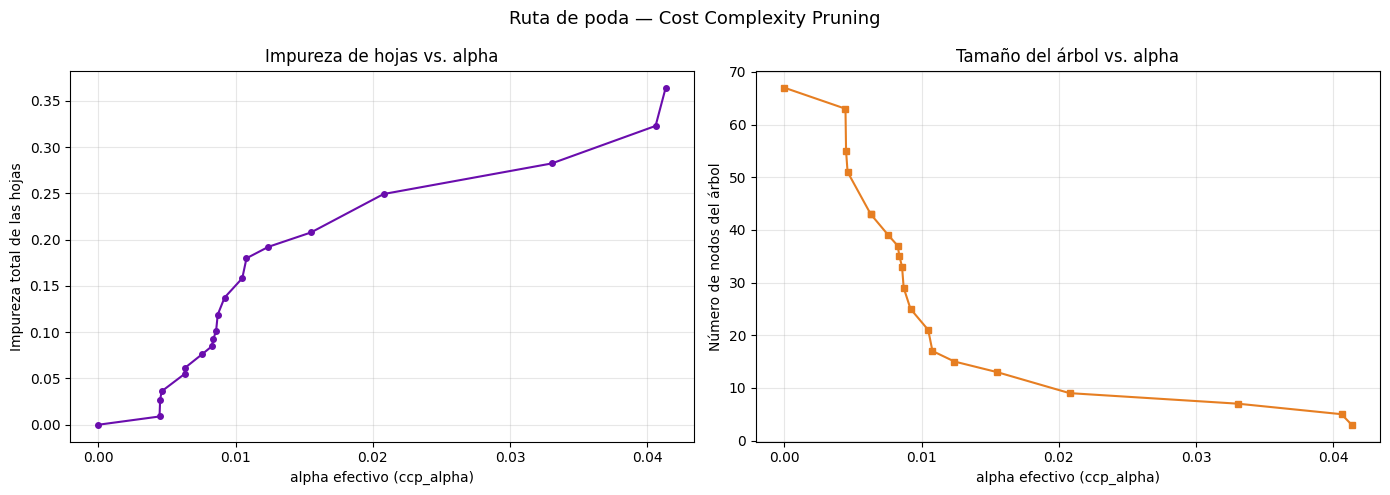

In [81]:
# Visualización: impureza de las hojas vs alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: impureza vs alpha
axes[0].plot(alphas[:-1], impurezas[:-1], marker="o", color="#6A0DAD", markersize=4)
axes[0].set_xlabel("alpha efectivo (ccp_alpha)")
axes[0].set_ylabel("Impureza total de las hojas")
axes[0].set_title("Impureza de hojas vs. alpha")
axes[0].grid(True, alpha=0.3)

# Gráfico 2: número de nodos vs alpha
n_nodos = []
for a in alphas[:-1]:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=123)
    clf.fit(X_train, y_train)
    n_nodos.append(clf.tree_.node_count)

axes[1].plot(alphas[:-1], n_nodos, marker="s", color="#E67E22", markersize=4)
axes[1].set_xlabel("alpha efectivo (ccp_alpha)")
axes[1].set_ylabel("Número de nodos del árbol")
axes[1].set_title("Tamaño del árbol vs. alpha")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Ruta de poda — Cost Complexity Pruning", fontsize=13)
plt.tight_layout()
plt.show()

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 4.1 — Interpretar la ruta de poda</p>

Observa la gráfica de "impureza de hojas vs. alpha" que acabas de generar.

**a)** A medida que alpha aumenta, la impureza total de las hojas:
`a)` aumenta &nbsp; `b)` disminuye &nbsp; `c)` se mantiene constante

**b)** ¿Por qué esta relación es siempre monótona (creciente), a diferencia de la relación profundidad-accuracy que sí tiene un máximo intermedio?
`a)` Porque alpha mide directamente cuánta poda se aplica: más poda siempre implica hojas menos puras, mientras que el accuracy depende del balance sesgo/varianza, que sí tiene un punto óptimo intermedio.
`b)` Porque el accuracy no depende de la profundidad.
`c)` Porque alpha e impureza no están relacionados.

</div>

In [82]:
respuesta_4_1a = "?"
respuesta_4_1b = "?"

verificar("ex4_1_impureza_alpha", respuesta_4_1a)
verificar("ex4_1_monotona", respuesta_4_1b)


Incorrecto, intenta de nuevo. Pista: Más poda (alpha alto) implica hojas más grandes y menos puras.
Incorrecto, intenta de nuevo. Pista: Alpha controla poda de forma directa; accuracy depende de un balance sesgo-varianza.


## <FONT SIZE=4 COLOR="green"> 4.2 Selección del alpha óptimo con validación cruzada </FONT>

Para encontrar el **mejor alpha** usamos validación cruzada (cross-validation).  
Entrenamos un árbol para cada valor de alpha y evaluamos el accuracy promedio en CV.  
El alpha óptimo es el que maximiza el accuracy de generalización.

In [83]:
# Accuracy de entrenamiento y prueba para cada alpha
train_acc_ccp = []
test_acc_ccp  = []

# Evitar alphas muy grandes (árbol trivial) tomando todos menos el último
alphas_cv = alphas[:-1]

for a in alphas_cv:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=123)
    clf.fit(X_train, y_train)
    train_acc_ccp.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc_ccp.append(accuracy_score(y_test,  clf.predict(X_test)))

# Encontrar el mejor alpha
best_alpha_idx = test_acc_ccp.index(max(test_acc_ccp))
best_alpha     = alphas_cv[best_alpha_idx]

print(f"Alpha óptimo:     {best_alpha:.6f}")
print(f"Accuracy (prueba): {max(test_acc_ccp):.4f}")

Alpha óptimo:     0.020780
Accuracy (prueba): 0.7802


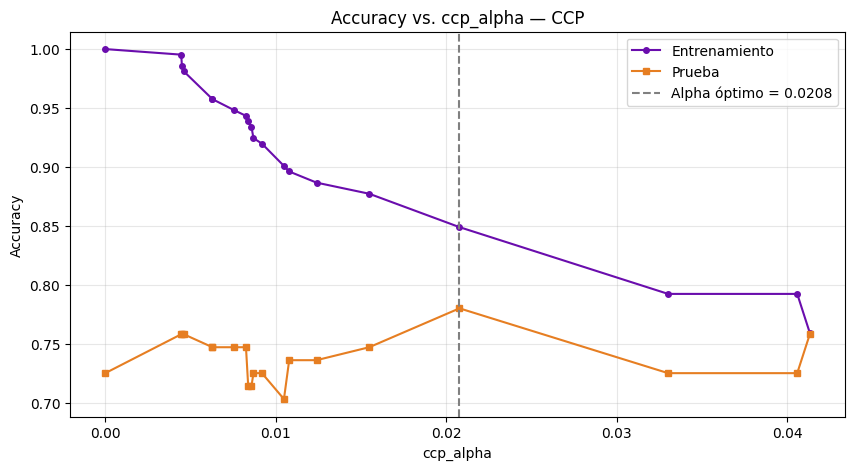

In [84]:
# Visualización
plt.figure(figsize=(10, 5))
plt.plot(alphas_cv, train_acc_ccp, marker="o", label="Entrenamiento", color="#6A0DAD", markersize=4)
plt.plot(alphas_cv, test_acc_ccp,  marker="s", label="Prueba",        color="#E67E22", markersize=4)
plt.axvline(best_alpha, linestyle="--", color="gray", label=f"Alpha óptimo = {best_alpha:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. ccp_alpha — CCP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 4.2 — Interpretar la gráfica de alpha vs accuracy (caso hipotético)</p>

Observa esta gráfica hipotética de CCP:

```
alpha       | Acc. Entrenamiento | Acc. Prueba
------------+---------------------+-------------
0.000       |       1.00         |    0.74
0.002       |       0.95         |    0.79
0.005       |       0.89         |    0.83
0.008       |       0.86         |    0.84
0.012       |       0.82         |    0.82
0.020       |       0.78         |    0.78
0.050       |       0.72         |    0.71
```

**a)** Con alpha = 0.000, ¿hay sobreajuste?
`a)` sí, el gap entre train y test es evidencia clara &nbsp; `b)` no &nbsp; `c)` no se puede determinar

*¿Cómo lo identificas?* — respóndelo abajo.

**b)** ¿Cuál sería el alpha óptimo?
`a)` 0.002 &nbsp; `b)` 0.008 &nbsp; `c)` 0.020

*¿Por qué?* — respóndelo abajo.

**c)** Con alpha = 0.050, el modelo está:
`a)` sobreajustado &nbsp; `b)` subajustado (train y test bajos y similares) &nbsp; `c)` en su punto óptimo

*¿Por qué?* — respóndelo abajo.

**d)** *(Reflexión, sin respuesta única)* ¿Por qué con alpha = 0.012 el accuracy de entrenamiento y de prueba son casi iguales (0.82)?

</div>

In [85]:
respuesta_4_2a = "?"
respuesta_4_2b = "?"
respuesta_4_2c = "?"

verificar("ex4_2_sobreajuste_alpha0", respuesta_4_2a)
verificar("ex4_2_alpha_optimo", respuesta_4_2b)
verificar("ex4_2_alpha050", respuesta_4_2c)

# a) ¿Cómo lo identificas? (no se verifica automáticamente):
#

# b) ¿Por qué? (no se verifica automáticamente):
#

# c) ¿Por qué? (no se verifica automáticamente):
#

# d) Tu respuesta (no se verifica automáticamente):
#


Incorrecto, intenta de nuevo. Pista: Compara 1.00 en entrenamiento contra 0.74 en prueba.
Incorrecto, intenta de nuevo. Pista: Busca el accuracy de prueba más alto en la tabla hipotética.
Incorrecto, intenta de nuevo. Pista: Con train y test bajos y parecidos, el árbol ya no tiene capacidad suficiente.


<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 4.3 — Análisis conceptual</p>

**a)** *(Reflexión, sin respuesta única)* En tus propias palabras, explica qué hace el parámetro alpha en el CCP. Usa una analogía que no sea técnica (por ejemplo: un árbol genealógico, un organigrama, un mapa mental, etc.)

**b)** Si el alpha óptimo encontrado es muy pequeño (cercano a 0), ¿qué nos dice eso sobre el árbol original?
`a)` Tenía poco sobreajuste (el árbol original ya generalizaba razonablemente bien)
`b)` Tenía mucho sobreajuste (necesitaba una poda agresiva)
`c)` No se puede determinar

**c)** ¿Por qué es importante usar el conjunto de **prueba** (y no el de entrenamiento) para seleccionar el alpha óptimo?
`a)` Porque seleccionar con el conjunto de entrenamiento siempre favorecería alpha=0 (el árbol más complejo), ya que ese es el que mejor ajusta esos mismos datos.
`b)` Porque el conjunto de entrenamiento no tiene suficientes datos.
`c)` No importa cuál se use.

*Justifica tu respuesta* — respóndelo abajo.

</div>

In [86]:
# a) Escribe tu analogía aquí (no se verifica automáticamente):
#

respuesta_4_3b = "?"
respuesta_4_3c = "?"

verificar("ex4_3_alpha_categoria", respuesta_4_3b)
verificar("ex4_3_test_no_train", respuesta_4_3c)

# c) Justifica tu respuesta (no se verifica automáticamente):
#


Incorrecto, intenta de nuevo. Pista: Un alpha cercano a 0 significa que casi no hace falta podar.
Incorrecto, intenta de nuevo. Pista: ¿Qué alpha minimizaría siempre el error de entrenamiento?


## <FONT SIZE=4 COLOR="green"> 4.3 Modelo final con CCP </FONT>

In [87]:
# Entrenamiento del modelo con el alpha óptimo
modelo_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=123)
modelo_ccp.fit(X_train, y_train)
y_pred_ccp = modelo_ccp.predict(X_test)

print(f"Profundidad del árbol podado: {modelo_ccp.get_depth()}")
print(f"Número de hojas:              {modelo_ccp.get_n_leaves()}")
print()
print("========== Evaluación — Árbol con CCP ==========")
print(classification_report(y_test, y_pred_ccp))

Profundidad del árbol podado: 3
Número de hojas:              5

========== Evaluación — Árbol con CCP ==========
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        41
           1       0.80      0.80      0.80        50

    accuracy                           0.78        91
   macro avg       0.78      0.78      0.78        91
weighted avg       0.78      0.78      0.78        91



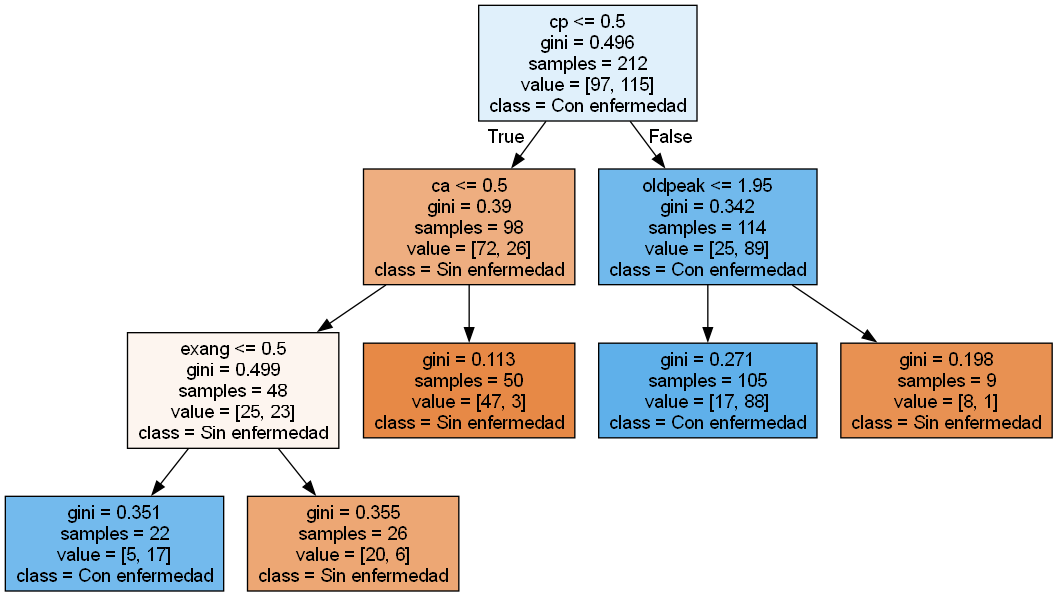

In [88]:
# Visualización del árbol podado con CCP
dot_ccp = export_graphviz(
    modelo_ccp,
    feature_names = X.columns,
    class_names   = ["Sin enfermedad", "Con enfermedad"],
    filled        = True
)
from IPython.display import Image
Image(Source(dot_ccp, format="png").pipe(format="png"), width=700)

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 4.4 — Comparar manualmente distintos alphas</p>

Elige 5 valores de alpha de la ruta de poda calculada y compara sus árboles resultantes:

```python
alphas_elegidos = [alphas_cv[0], alphas_cv[5], alphas_cv[10], alphas_cv[15], alphas_cv[-1]]

for a in alphas_elegidos:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=123)
    clf.fit(X_train, y_train)
    print(f"alpha={a:.5f} | profundidad={clf.get_depth()} | hojas={clf.get_n_leaves()} "
          f"| Acc prueba={accuracy_score(y_test, clf.predict(X_test)):.3f}")
```

¿Cuál es la relación entre alpha, profundidad y accuracy? ¿Siempre más simple es mejor? (Coméntalo en el código, no hace falta un checker para esta reflexión.)

---

</div>

In [89]:
# Tu código aquí

# <FONT SIZE=5 COLOR="green"> 5. Importancia de las características </FONT>


Una de las ventajas más grandes de los árboles de decisión es que nos dicen qué variables fueron más útiles para hacer las predicciones. A esto se le llama **feature importance** (importancia de las características).

La importancia de cada variable se calcula como la suma de las reducciones de impureza (Gini) que esa variable logró en todos los nodos donde fue usada, ponderada por el número de observaciones. Cuanto mayor sea este número, más veces el árbol decidió usar esa variable para separar los grupos.

In [90]:
# Importancia de variables del árbol con CCP
importancia = pd.DataFrame({
    "predictor":   X_train.columns.tolist(),
    "importancia": modelo_ccp.feature_importances_
}).sort_values("importancia", ascending=False)

print("Importancia de las variables — Árbol con CCP")
print("----------------------------------------------")
importancia

Importancia de las variables — Árbol con CCP
----------------------------------------------


,predictor,importancia
2,cp,0.534647
9,oldpeak,0.167328
11,ca,0.164342
8,exang,0.133683
0,age,0.000000
1,sex,0.000000
3,trestbps,0.000000
4,chol,0.000000
5,fbs,0.000000
6,restecg,0.000000


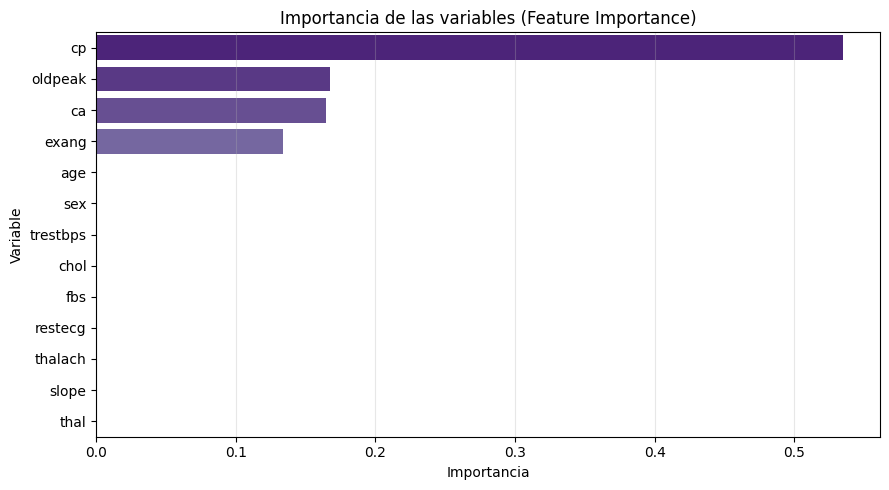

In [91]:
# Gráfico de importancia
plt.figure(figsize=(9, 5))
sns.barplot(data=importancia, x="importancia", y="predictor",
            palette="Purples_r")
plt.title("Importancia de las variables (Feature Importance)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 5.1 — Interpretar la importancia de variables</p>

**a)** Según tu gráfico, ¿cuál es la variable más importante?
`a)` age &nbsp; `b)` cp &nbsp; `c)` chol

**b)** ¿Tiene sentido clínico que esa variable sea la más relevante para predecir enfermedad cardíaca?
`a)` Sí, el dolor torácico (cp) es uno de los síntomas cardinales usados clínicamente para sospechar enfermedad coronaria.
`b)` No, es una variable irrelevante.
`c)` No se puede saber sin más contexto.

</div>

In [92]:
top_variable = importancia.iloc[0]["predictor"]
print("Variable más importante:", top_variable)

respuesta_5_1a = "?"
respuesta_5_1b = "?"

verificar("ex5_1_top_var", respuesta_5_1a)
verificar("ex5_1_sentido_clinico", respuesta_5_1b)


Variable más importante: cp
Incorrecto, intenta de nuevo. Pista: Es la misma variable que resultó ser la raíz del árbol en la sección 2.3.
Incorrecto, intenta de nuevo. Pista: Piensa en cómo se diagnostica clínicamente una posible enfermedad cardíaca.


# <FONT SIZE=5 COLOR="green"> 6. Comparación de modelos </FONT>

Ahora comparemos los tres árboles que entrenamos: sin poda, con pre-poda y con CCP (post-poda). La pregunta clave es: **¿Vale la pena la complejidad extra de la poda?**

In [93]:
# Tabla comparativa de los tres árboles
modelos = {
    "Árbol sin poda":  (modelo_tree,    X_test,  y_test),
    "Pre-poda":        (modelo_prepoda, X_test,  y_test),
    "CCP (post-poda)": (modelo_ccp,     X_test,  y_test),
}

rows = []
for nombre, (m, Xt, yt) in modelos.items():
    yp = m.predict(Xt)
    rows.append({
        "Modelo":        nombre,
        "Profundidad":   m.get_depth(),
        "Hojas":         m.get_n_leaves(),
        "Accuracy":      round(accuracy_score(yt, yp), 4),
        "Recall":        round(recall_score(yt, yp), 4),
        "Specificidad":  round(specificity_score(yt, yp), 4),
        "Precision":     round(precision_score(yt, yp), 4),
        "F1":            round(f1_score(yt, yp), 4),
    })

comparacion = pd.DataFrame(rows).set_index("Modelo")
comparacion

,Profundidad,Hojas,Accuracy,Recall,Specificidad,Precision,F1
Modelo,,,,,,,
Árbol sin poda,9,34,0.7253,0.66,0.8049,0.8049,0.7253
Pre-poda,3,8,0.8132,0.86,0.7561,0.8113,0.8350
CCP (post-poda),3,5,0.7802,0.80,0.7561,0.8000,0.8000


<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 6.1 — Interpretar la tabla comparativa</p>

**a)** ¿Cuál de los tres modelos tiene **menos hojas**?
`a)` Árbol sin poda &nbsp; `b)` Pre-poda &nbsp; `c)` CCP (post-poda)

**b)** ¿El modelo con mejor accuracy es siempre el más recomendable?
`a)` No necesariamente; en un contexto clínico, priorizar recall (detectar enfermos) puede ser más importante que el accuracy global.
`b)` Sí, siempre hay que elegir el de mayor accuracy.
`c)` El accuracy es la única métrica relevante en cualquier contexto.

**c)** *(Reflexión, sin respuesta única)* Si tuvieras que recomendar uno de los tres árboles a un equipo médico, ¿cuál elegirías y por qué? Justifica con al menos dos métricas de tu tabla.

</div>

In [94]:
respuesta_6_1a = "?"
respuesta_6_1b = "?"

verificar("ex6_1_menos_hojas", respuesta_6_1a)
verificar("ex6_1_accuracy_siempre", respuesta_6_1b)

# c) Escribe tu recomendación y justificación aquí (no se verifica automáticamente):
#


Incorrecto, intenta de nuevo. Pista: Compara la columna 'Hojas' de tu tabla comparativa entre los tres modelos.
Incorrecto, intenta de nuevo. Pista: En medicina, dejar pasar un enfermo puede ser más costoso que una falsa alarma.


# <FONT SIZE=5 COLOR="green"> 7. Curva ROC </FONT>

Ya vimos la curva ROC en la sesión anterior. Aquí la usamos para comparar los tres árboles que entrenamos: sin poda, con pre-poda y con CCP.

Recuerda: queremos que la curva esté lo más cerca posible de la esquina superior izquierda. El AUC resume esto en un número entre 0 y 1.

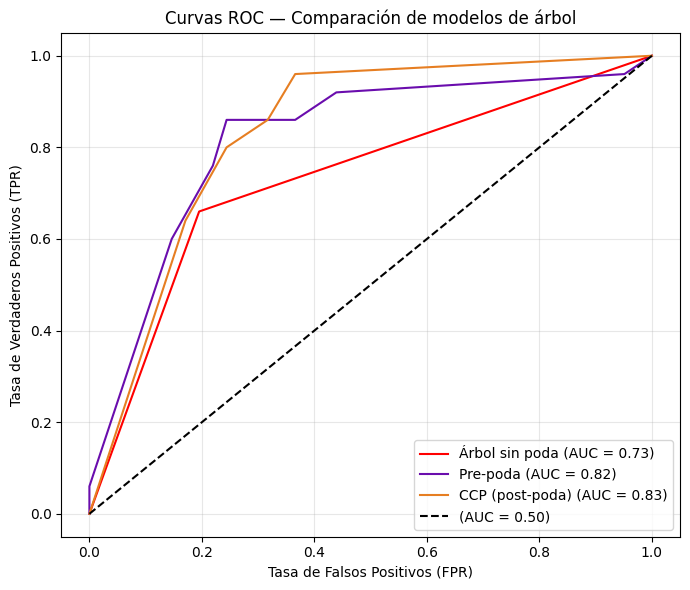

In [95]:
# Curvas ROC de los tres modelos
fig, ax = plt.subplots(figsize=(7, 6))

colores = {"Árbol sin poda": "red", "Pre-poda": "#6A0DAD", "CCP (post-poda)": "#E67E22"}

for nombre, (m, Xt, yt) in modelos.items():
    proba = m.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(yt, proba)
    auc = roc_auc_score(yt, proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.2f})", color=colores[nombre])

ax.plot([0, 1], [0, 1], "k--", label="(AUC = 0.50)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curvas ROC — Comparación de modelos de árbol")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 7.1 — Comparar curvas ROC</p>

**a)** ¿Cuál de los tres modelos tiene el **AUC más alto**?
`a)` Árbol sin poda &nbsp; `b)` Pre-poda &nbsp; `c)` CCP

**b)** En tu tabla de la sección 6, el mejor accuracy lo tenía otro modelo. ¿Qué te dice esa diferencia?
`a)` El modelo con mejor accuracy en el umbral por defecto (0.5) no es necesariamente el que mejor separa las clases en general; el AUC evalúa el modelo en todos los umbrales posibles.
`b)` Accuracy y AUC siempre deben coincidir.
`c)` El AUC no es una métrica confiable.

</div>

In [96]:
respuesta_7_1a = "?"
respuesta_7_1b = "?"

verificar("ex7_1_auc_max", respuesta_7_1a)
verificar("ex7_1_accuracy_vs_auc", respuesta_7_1b)


Incorrecto, intenta de nuevo. Pista: Revisa el valor de AUC en la leyenda de cada curva.
Incorrecto, intenta de nuevo. Pista: El accuracy usa un único umbral (0.5); el AUC evalúa todos los umbrales posibles.


# <FONT SIZE=5 COLOR="green"> 8. Resumen </FONT>

Hemos trabajado tres variantes del mismo modelo de **árbol de decisión** sobre la base de datos de enfermedades cardíacas:

1. **Árbol sin poda**: el modelo crece al máximo, clasificando perfectamente el entrenamiento pero con overfitting en prueba.

2. **Pre-poda (max_depth)**: al limitar la profundidad, logramos un árbol más sencillo y con mejor generalización. Es la estrategia más rápida y directa.

3. **Post-poda con CCP**: el método más sofisticado. Dejamos que el árbol crezca y luego encontramos el parámetro $\alpha$ óptimo usando la ruta de poda. Es el enfoque recomendado por scikit-learn.

**Regla general:** siempre que un árbol sin restricciones muestre un accuracy de entrenamiento mucho mayor que el de prueba, es señal de sobreajuste → aplicar poda.

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Reto final — Ejercicio integrador</p>

Ahora que conoces las tres estrategias (sin poda, pre-poda y CCP), pon a prueba lo aprendido con el criterio de **entropía**.

**a)** Completa el código: entrena un árbol con `criterion="entropy"`, calcula su ruta de poda (CCP) y encuentra el alpha óptimo igual que en la sección 4.

</div>

In [97]:
tree_entropy = DecisionTreeClassifier(random_state=123, criterion="entropy")
path_entropy = tree_entropy.cost_complexity_pruning_path(X_train, y_train)
alphas_entropy = path_entropy.ccp_alphas[:-1]

test_acc_entropy = []
for a in alphas_entropy:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=123, criterion="entropy")
    clf.fit(X_train, y_train)
    test_acc_entropy.append(accuracy_score(y_test, clf.predict(X_test)))

best_alpha_entropy = alphas_entropy[test_acc_entropy.index(max(test_acc_entropy))]
modelo_ccp_entropy = DecisionTreeClassifier(ccp_alpha=best_alpha_entropy, random_state=123, criterion="entropy")
modelo_ccp_entropy.fit(X_train, y_train)

print(f"Alpha óptimo (entropy): {best_alpha_entropy:.5f}")
print(f"Accuracy prueba (entropy): {max(test_acc_entropy):.4f}")
print(f"Accuracy prueba (gini, sección 4): {accuracy_score(y_test, modelo_ccp.predict(X_test)):.4f}")


Alpha óptimo (entropy): 0.02071
Accuracy prueba (entropy): 0.7802
Accuracy prueba (gini, sección 4): 0.7802


<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

**b)** Comparando el accuracy de prueba de ambas versiones (gini vs. entropy):
`a)` prácticamente idéntico (~0.78 ambos) &nbsp; `b)` entropy fue mucho mejor &nbsp; `c)` entropy fue mucho peor

**c)** En un párrafo breve, resume cuál de las variantes de árbol (sin poda, pre-poda, CCP-gini, CCP-entropy) recomendarías para este problema de diagnóstico y por qué, considerando desempeño e interpretabilidad.

</div>

In [98]:
respuesta_8_1b = "?"
verificar("ex8_1_entropy_vs_gini", respuesta_8_1b)


Incorrecto, intenta de nuevo. Pista: Compara los dos accuracy de prueba que imprimiste: ¿difieren mucho o poco?
